# **Cost Aware Portfolio Optimization**  

---
**This notebook is the initial proof of concept**  

**Authors:** Bradley Scott, Sriram Vema, Christian Jarett Rivera  
**Last Date:** 20 Apr 2026  

---

In [49]:
'''
[BS04192026] opt_ini_000001
[BS04192026] Import required modules and suppress bounds warnings.
'''
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", message="Values in x were outside bounds")

In [50]:
'''
[BS04192026] opt_ini_000005
[BS04192026] Build function to grab data from yfinance
'''
class Processor:
    def __init__(self, tickers=None, lookback_years=5):
        self.tickers = tickers or ["SPY", "TLT", "GLD"]

        self.start_date = (
            datetime.today() - timedelta(days=365 * lookback_years)
        ).strftime("%Y-%m-%d")

        self.end_date = datetime.today().strftime("%Y-%m-%d")

        self.daily_log_returns = None
        self.monthly_returns = None

    def run(self):
        raw = yf.download(
            self.tickers,
            start=self.start_date,
            end=self.end_date,
            auto_adjust=True,
            progress=False
        )

        raw.columns = ["_".join([c[1], c[0]]) for c in raw.columns]

        close_cols = [f"{t}_Close" for t in self.tickers]
        prices = raw[close_cols].copy()
        prices.columns = self.tickers

        self.daily_log_returns = np.log(prices / prices.shift(1)).dropna()

        monthly_prices = prices.resample("ME").last()
        self.monthly_returns = monthly_prices.pct_change().dropna()

In [51]:
'''
[BS04192026] opt_ini_000010
[BS04192026] Build function that looks on the previous 12+ months only (to avoid data leakage) 
    and decides if a month is low or high volatility based on a 20% high volatility assumption. 
'''
def compute_regimes(monthly_vol, lookback_min=12, high_pct=0.8):
    regimes = pd.Series(index=monthly_vol.index, dtype=int)

    for i in range(lookback_min, len(monthly_vol)):
        threshold = monthly_vol.iloc[:i].quantile(high_pct)
        regimes.iloc[i] = 2 if monthly_vol.iloc[i] >= threshold else 1

    return regimes

In [52]:
'''
[BS04192026] opt_ini_000015
[BS04192026] Build the optimization function
'''
c_per_ticker = np.array([0.0003, 0.0004, 0.0003]) 
#c_per_ticker = np.array([0.001, 0.001, 0.001]) 

def objective(w, mu, cov, w_prev, gamma, lam, c_array):
    ret = mu @ w
    risk = (gamma / 2) * (w @ cov @ w)
    # Element‑wise multiplication of cost array with absolute weight changes
    cost = lam * np.sum(c_array * np.abs(w - w_prev))
    return -(ret - risk - cost)

In [53]:
'''
[BS04192026] opt_ini_000020
[BS04192026] Build out the optimizer function and return the optimal weights.
    NB: Using SLSQP since it can handle non-differentiable objective functions because
        where w  = w_prev so |w - w_prev| = 0 the objective function is non differentiable
    NB: C = 0.001 is a common starting point but it may need to be raised and the Sharpe results
        compared to see how robust this is against more real world trading costs
'''
def optimize_weights(mu, cov, w_prev, gamma, lam, c=0.001,
                     bounds=(0.1, 0.8)):
    n = len(mu)
    x0 = w_prev if w_prev is not None else np.ones(n) / n
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]
    bounds_list = [bounds] * n
    result = minimize(
        objective, x0,
        args=(mu, cov, w_prev, gamma, lam, c),
        method='SLSQP',
        bounds=bounds_list,
        constraints=constraints,
        options={'maxiter': 200, 'ftol': 1e-8}
    )
    return result.x

In [54]:
'''
[BS04192026] opt_ini_000025
[BS04192026] Build out the function to run the backtest
'''
def run_backtest(proc, gamma=1.0, lam=1.0, c=0.001):
    monthly_vol = (
        proc.daily_log_returns["SPY"]
        .resample("ME")
        .std() * np.sqrt(252)
    ).dropna()

    monthly_ret = proc.monthly_returns.copy()

    common_idx = monthly_vol.index.intersection(monthly_ret.index)
    monthly_vol = monthly_vol.loc[common_idx]
    monthly_ret = monthly_ret.loc[common_idx]

    regimes = compute_regimes(monthly_vol)

    regime_map = regimes.copy()
    regime_map.index = regime_map.index.to_period("M")

    w_prev = np.ones(len(proc.tickers)) / len(proc.tickers)

    gross_values = [1.0]
    net_values = [1.0]

    weights_history = []
    turnovers = []
    rebalance_log = []

    cumulative_cost = 0

    valid_months = regimes.dropna().index

    for t in range(1, len(valid_months)):
        current_month = valid_months[t]
        prev_month = valid_months[t - 1]

        regime = regimes.loc[prev_month]

        hist = proc.daily_log_returns.loc[:prev_month]

        daily_regime = pd.Series(
            [regime_map.get(d.to_period("M"), np.nan) for d in hist.index],
            index=hist.index
        )

        idx = daily_regime[daily_regime == regime].index

        subset = hist.loc[idx] if len(idx) >= 20 else hist

        mu = np.clip(subset.mean().values * 21, -0.05, 0.05)
        cov = subset.cov().values * 21

        w_new = optimize_weights(mu, cov, w_prev, gamma, lam, c_per_ticker)

        weight_change = np.abs(w_new - w_prev)
        turnover = np.sum(weight_change)
        trade_cost = np.sum(c_per_ticker * weight_change)

        realized_ret = monthly_ret.loc[current_month].values

        gross_ret = np.dot(w_new, realized_ret)
        net_ret = gross_ret - trade_cost

        gross_values.append(gross_values[-1] * (1 + gross_ret))
        net_values.append(net_values[-1] * (1 + net_ret))

        cumulative_cost += trade_cost

        row = {
            "date": prev_month,
            "regime": regime,
            "gamma": gamma,
            "lambda": lam,
            "turnover": turnover,
            "trade_cost": trade_cost,
            "gross_return": gross_ret,
            "net_return": net_ret
        }

        for i, ticker in enumerate(proc.tickers):
            row[f"{ticker}_prev"] = w_prev[i]
            row[f"{ticker}_new"] = w_new[i]
            row[f"{ticker}_mu"] = mu[i]

        rebalance_log.append(row)

        weights_history.append(w_new)
        turnovers.append(turnover)
        w_prev = w_new

    net_rets = pd.Series(net_values).pct_change().dropna()

    sharpe = np.sqrt(12) * net_rets.mean() / net_rets.std()

    return {
        "sharpe": sharpe,
        "total_return": net_values[-1] - 1,
        "gross_values": np.array(gross_values),
        "net_values": np.array(net_values),
        "weights_history": weights_history,
        "turnovers": turnovers,
        "rebalance_log": pd.DataFrame(rebalance_log),
        "cumulative_cost": cumulative_cost
    }

In [55]:
'''
[BS04192026] opt_ini_000030
[BS04192026] Run the processor and do the grid search 
'''
proc = Processor()
proc.run()

# aiming for an expanded grid search that has lambda so high that the model stops trading
# at lambda = 50 we've effectively stopped trading
gamma_candidates = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]
lambda_candidates = [0.0, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]

results = []
best_sharpe = -np.inf
best_gamma = None
best_lambda = None

for gamma in gamma_candidates:
    for lam in lambda_candidates:
        metrics = run_backtest(proc, gamma=gamma, lam=lam)

        results.append({
            "gamma": gamma,
            "lambda": lam,
            "sharpe": metrics["sharpe"],
            "total_return": metrics["total_return"],
            "cumulative_cost": metrics["cumulative_cost"]
        })

        if metrics["sharpe"] > best_sharpe:
            best_sharpe = metrics["sharpe"]
            best_gamma = gamma
            best_lambda = lam

In [56]:
'''
[BS04192026] opt_ini_000031
[BS04192026] Determine the equal 1/3 weight sharpe for comparison
'''
bench_ret = proc.monthly_returns.mean(axis=1)  # equal‑weight monthly returns
bench_sharpe = np.sqrt(12) * bench_ret.mean() / bench_ret.std()
print(f"Equal‑Weight Benchmark Sharpe: {bench_sharpe:.4f}")

Equal‑Weight Benchmark Sharpe: 0.8359


In [57]:
'''
[BS04192026] opt_ini_000032
[BS04192026] Determine 100% SPY sharpe
'''
# Extract SPY monthly returns
spy_returns = proc.monthly_returns["SPY"]

# Annualized Sharpe (assuming risk‑free rate = 0)
spy_sharpe = np.sqrt(12) * spy_returns.mean() / spy_returns.std()

print(f"100% SPY Sharpe: {spy_sharpe:.4f}")

100% SPY Sharpe: 0.8498


    gamma  lambda    sharpe  total_return  cumulative_cost
54   20.0    20.0  1.362307      0.926939         0.001453
53   20.0    10.0  1.328303      0.857818         0.001693
46   10.0    20.0  1.302940      0.923253         0.001629
48   20.0     0.0  1.289090      0.803408         0.002740
52   20.0     5.0  1.286428      0.807961         0.001956
49   20.0     0.5  1.284259      0.798811         0.002629
50   20.0     1.0  1.278404      0.793410         0.002529
51   20.0     2.0  1.270329      0.787169         0.002344
38    5.0    20.0  1.251490      0.955764         0.001777
45   10.0    10.0  1.215335      0.785499         0.002113
40   10.0     0.0  1.186450      0.733676         0.003668
30    2.0    20.0  1.183983      0.909740         0.002176
41   10.0     0.5  1.171808      0.720744         0.003534
42   10.0     1.0  1.158036      0.709313         0.003403
44   10.0     5.0  1.154907      0.715495         0.002550
5     0.1    10.0  1.142037      0.900567         0.0025

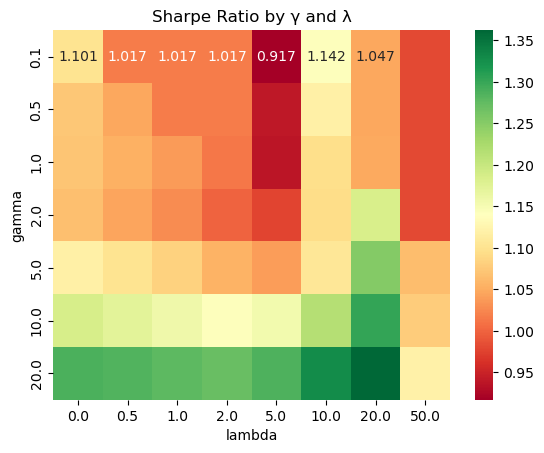

In [58]:
'''
[BS04192026] opt_ini_000035
[BS04192026] View the results of the grid search
'''
results_df = pd.DataFrame(results)
print(results_df.sort_values("sharpe", ascending=False))

pivot = results_df.pivot(index="gamma", columns="lambda", values="sharpe")
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn")
plt.title("Sharpe Ratio by γ and λ")
plt.show()


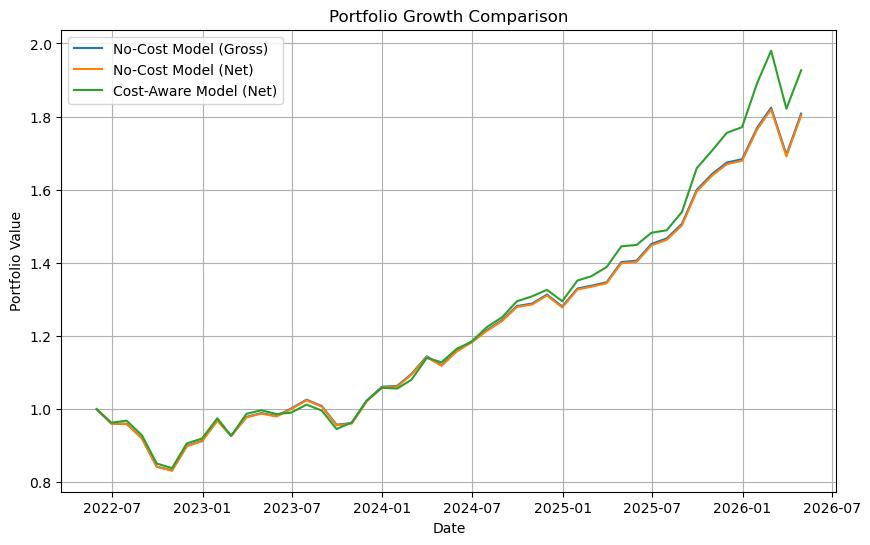

In [59]:
'''
[BS04192026] opt_ini_000040
[BS04192026] Compare the cost aware vs. no cost returns
'''
cost_unaware = run_backtest(proc, gamma=best_gamma, lam=0)
cost_aware = run_backtest(proc, gamma=best_gamma, lam=best_lambda)

cost_aware["rebalance_log"].to_csv("best_rebalance_log.csv", index=False)

dates = proc.monthly_returns.index[-len(cost_aware["net_values"]):]

plt.figure(figsize=(10, 6))
plt.plot(dates, cost_unaware["gross_values"], label="No-Cost Model (Gross)")
plt.plot(dates, cost_unaware["net_values"], label="No-Cost Model (Net)")
plt.plot(dates, cost_aware["net_values"], label="Cost-Aware Model (Net)")
plt.title("Portfolio Growth Comparison")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

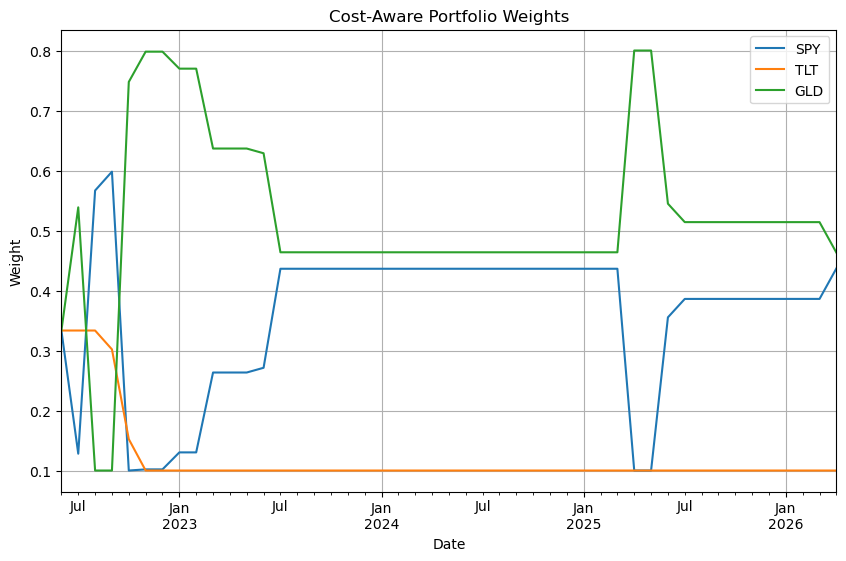

In [60]:
'''
[BS04192026] opt_ini_000045
[BS04192026] View the cost aware portfolio allocations over time
'''
weights_df = pd.DataFrame(
    cost_aware["weights_history"],
    columns=proc.tickers,
    index=dates[1:]
)

weights_df.plot(figsize=(10, 6))
plt.title("Cost-Aware Portfolio Weights")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.grid(True)
plt.show()


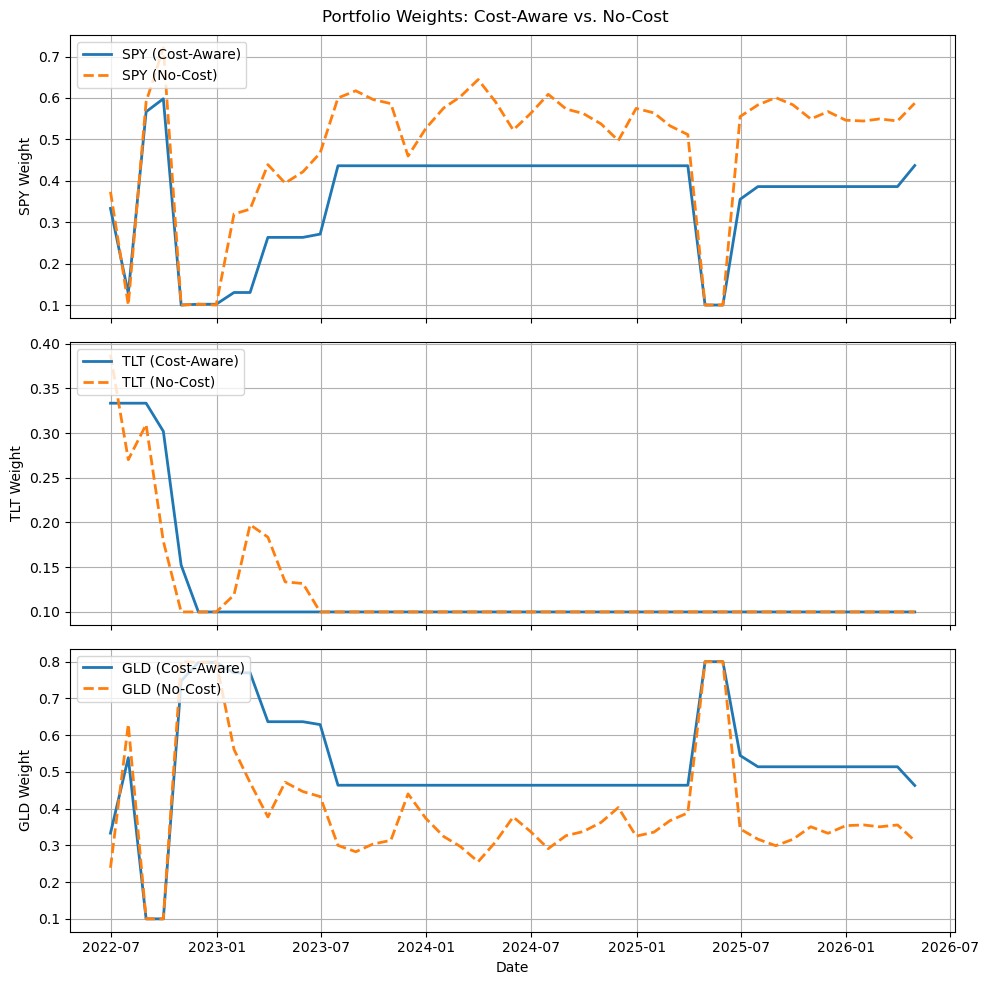

In [61]:
'''
[BS04192026] opt_ini_000050
[BS04192026] Compare the cost aware and cost unaware portfolio allocations
'''
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

for i, ticker in enumerate(proc.tickers):
    ax = axes[i]
    # Cost-aware weights
    ax.plot(dates[1:], [w[i] for w in cost_aware["weights_history"]],
            label=f"{ticker} (Cost-Aware)", linewidth=2)
    # No-cost weights
    ax.plot(dates[1:], [w[i] for w in cost_unaware["weights_history"]],
            label=f"{ticker} (No-Cost)", linestyle="--", linewidth=2)
    ax.set_ylabel(f"{ticker} Weight")
    ax.legend(loc="upper left")
    ax.grid(True)

axes[-1].set_xlabel("Date")
fig.suptitle("Portfolio Weights: Cost-Aware vs. No-Cost")
plt.tight_layout()
plt.show()

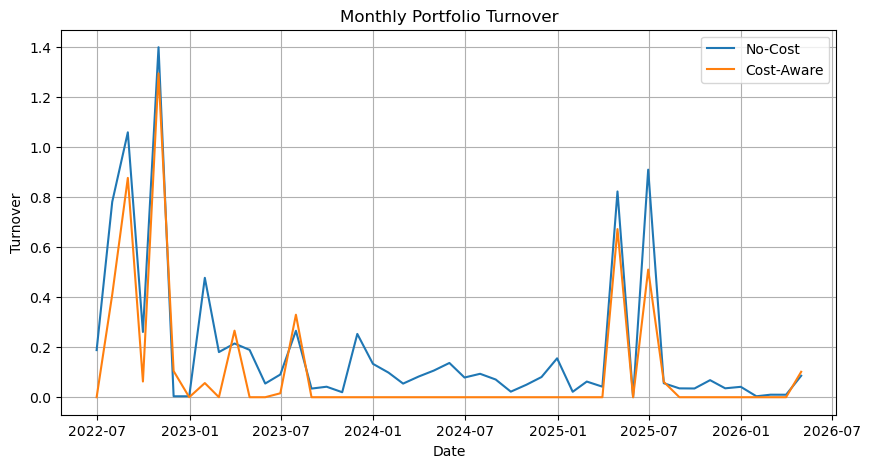

In [62]:
'''
[BS04192026] opt_ini_000055
[BS04192026] Compare the monthly portfolio turnover between cost aware and cost unaware
'''
plt.figure(figsize=(10, 5))
plt.plot(dates[1:], cost_unaware["turnovers"], label="No-Cost")
plt.plot(dates[1:], cost_aware["turnovers"], label="Cost-Aware")
plt.title("Monthly Portfolio Turnover")
plt.xlabel("Date")
plt.ylabel("Turnover")
plt.legend()
plt.grid(True)
plt.show()

In [63]:
'''
[BS04192026] opt_ini_000060
[BS04192026] Compare the final numbers
'''
print("\nBest Parameters")
print("Gamma:", best_gamma)
print("Lambda:", best_lambda)

print("\nNo-Cost Strategy")
print("Sharpe:", round(cost_unaware["sharpe"], 4))
print("Total Return:", round(cost_unaware["total_return"], 4))
print("Cumulative Cost:", round(cost_unaware["cumulative_cost"], 4))

print("\nCost-Aware Strategy")
print("Sharpe:", round(cost_aware["sharpe"], 4))
print("Total Return:", round(cost_aware["total_return"], 4))
print("Cumulative Cost:", round(cost_aware["cumulative_cost"], 4))


Best Parameters
Gamma: 20.0
Lambda: 20.0

No-Cost Strategy
Sharpe: 1.2891
Total Return: 0.8034
Cumulative Cost: 0.0027

Cost-Aware Strategy
Sharpe: 1.3623
Total Return: 0.9269
Cumulative Cost: 0.0015


In [64]:
# %%
'''
[BS04192026] opt_ini_000065
[BS04192026] Get an out of sample result by training on 2021-2024 and testing on 2024-2025
    and then training on 2022-2025 and testing on 2025-2026
'''
# Lightweight container to hold sliced data
class DataSlice:
    def __init__(self, daily_log_returns, monthly_returns, tickers):
        self.daily_log_returns = daily_log_returns
        self.monthly_returns = monthly_returns
        self.tickers = tickers

# Train on first 3 years, test on last 2 years
cutoff = proc.monthly_returns.index[0] + pd.DateOffset(years=3)

train_mask = proc.monthly_returns.index < cutoff
test_mask = proc.monthly_returns.index >= cutoff

monthly_train = proc.monthly_returns[train_mask]
daily_train = proc.daily_log_returns.loc[:monthly_train.index[-1]]
train_slice = DataSlice(daily_train, monthly_train, proc.tickers)

monthly_test = proc.monthly_returns[test_mask]
daily_test = proc.daily_log_returns.loc[monthly_test.index[0]:monthly_test.index[-1]]
test_slice = DataSlice(daily_test, monthly_test, proc.tickers)

# Find best parameters on train
best_sharpe = -np.inf
best_g, best_l = None, None
for g in gamma_candidates:
    for l in lambda_candidates:
        met = run_backtest(train_slice, gamma=g, lam=l)
        if met["sharpe"] > best_sharpe:
            best_sharpe = met["sharpe"]
            best_g, best_l = g, l

print(f"Best params from train: gamma={best_g}, lambda={best_l}, train Sharpe={best_sharpe:.3f}")

# Test on unseen data
test_met = run_backtest(test_slice, gamma=best_g, lam=best_l)
print(f"Out-of-sample Sharpe: {test_met['sharpe']:.3f}")
print(f"Out-of-sample Total Return: {test_met['total_return']:.3f}")

Best params from train: gamma=0.1, lambda=2.0, train Sharpe=0.574
Out-of-sample Sharpe: 1.790
Out-of-sample Total Return: 0.285
